<a href="https://colab.research.google.com/github/RamonEppens/Analisis_Predictivo_Co2/blob/main/notebooks/Examen1-An%C3%A1lisisPredictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo — Examen 1
## Predicción de emisiones de CO₂ per cápita por país
**Dataset:** Our World in Data — CO2 and Greenhouse Gas Emissions  
**Fuente:** github.com/owid/co2-data  
**Grupo:** Ramón Eppens · Moira Patricia Clacin · María Belen Piuma Justo

**ITBA — 2026**

In [54]:
# === LIBRERÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual general
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print("Librerías cargadas correctamente. ")

Librerías cargadas correctamente. 


In [55]:
# === CARGA DEL DATASET ===
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

print(f"Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado correctamente.
Dimensiones: 50,411 filas × 79 columnas


In [56]:
# === PRIMER VISTAZO ===
df.head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,1755,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,1756,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,1757,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,1758,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,1759,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
# Tipos de datos por columna
df.dtypes.value_counts()

,count
float64,76
object,2
int64,1


In [58]:
# Ver todas las columnas disponibles
for i, col in enumerate(df.columns):
    print(f"{i+1:>3}. {col}")

  1. country
  2. year
  3. iso_code
  4. population
  5. gdp
  6. cement_co2
  7. cement_co2_per_capita
  8. co2
  9. co2_growth_abs
 10. co2_growth_prct
 11. co2_including_luc
 12. co2_including_luc_growth_abs
 13. co2_including_luc_growth_prct
 14. co2_including_luc_per_capita
 15. co2_including_luc_per_gdp
 16. co2_including_luc_per_unit_energy
 17. co2_per_capita
 18. co2_per_gdp
 19. co2_per_unit_energy
 20. coal_co2
 21. coal_co2_per_capita
 22. consumption_co2
 23. consumption_co2_per_capita
 24. consumption_co2_per_gdp
 25. cumulative_cement_co2
 26. cumulative_co2
 27. cumulative_co2_including_luc
 28. cumulative_coal_co2
 29. cumulative_flaring_co2
 30. cumulative_gas_co2
 31. cumulative_luc_co2
 32. cumulative_oil_co2
 33. cumulative_other_co2
 34. energy_per_capita
 35. energy_per_gdp
 36. flaring_co2
 37. flaring_co2_per_capita
 38. gas_co2
 39. gas_co2_per_capita
 40. ghg_excluding_lucf_per_capita
 41. ghg_per_capita
 42. land_use_change_co2
 43. land_use_change_co2_per_

## 1. Descripción general del dataset

In [59]:
# === DIMENSIONES Y TIPOS DE DATOS ===
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

Filas:    50,411
Columnas: 79

Tipos de datos:
float64    76
object      2
int64       1
Name: count, dtype: int64


In [60]:
# === INFO GENERAL ===
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

### 1.1 Estadísticas descriptivas

In [61]:
# === ESTADÍSTICAS DESCRIPTIVAS ===
# Solo columnas numéricas, redondeado a 2 decimales
df.describe().round(2)

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.00,4.116700e+04,1.525100e+04,29173.00,25648.00,29384.00,27216.00,26239.00,23796.00,23496.00,...,2170.00,41238.00,38280.00,41238.00,41238.00,38280.00,38150.00,37813.00,4712.00,4712.00
mean,1920.35,6.017453e+07,3.300495e+11,7.89,0.06,420.23,6.27,42.60,544.14,7.48,...,7.19,2.27,0.00,0.01,0.01,0.00,490.80,310.52,-6.99,21.47
std,65.86,3.308433e+08,3.086383e+12,62.99,0.12,1972.09,62.20,1721.91,2273.28,99.51,...,17.45,9.28,0.02,0.05,0.06,0.00,2414.08,1812.36,259.02,62.64
min,1750.00,2.150000e+02,4.998000e+07,0.00,0.00,0.00,-1928.34,-100.00,-84.56,-2298.98,...,0.00,-0.82,-0.00,0.00,-0.00,0.00,-19.73,0.00,-2177.81,-98.28
25%,1875.00,3.272140e+05,7.874038e+09,0.00,0.00,0.38,-0.00,-1.07,6.67,-0.73,...,0.14,0.00,0.00,0.00,0.00,0.00,1.50,0.22,-2.26,-6.83
50%,1925.00,2.291594e+06,2.743861e+10,0.00,0.00,5.08,0.04,3.81,28.12,0.11,...,0.59,0.08,0.00,0.00,0.00,0.00,14.61,2.22,1.64,8.38
75%,1975.00,9.986553e+06,1.212627e+11,0.52,0.08,53.66,1.02,10.88,124.30,2.77,...,2.42,0.37,0.00,0.00,0.00,0.00,76.51,27.86,11.43,32.78
max,2024.00,8.161973e+09,1.301126e+14,1666.88,2.48,38598.58,1804.66,180870.00,43184.09,2614.87,...,100.00,100.00,0.38,1.22,1.68,0.08,54433.40,43714.78,1768.85,1023.04


### 1.2 Valores faltantes

Columnas con valores faltantes: 77 de 79
Columnas sin ningún nulo:       2



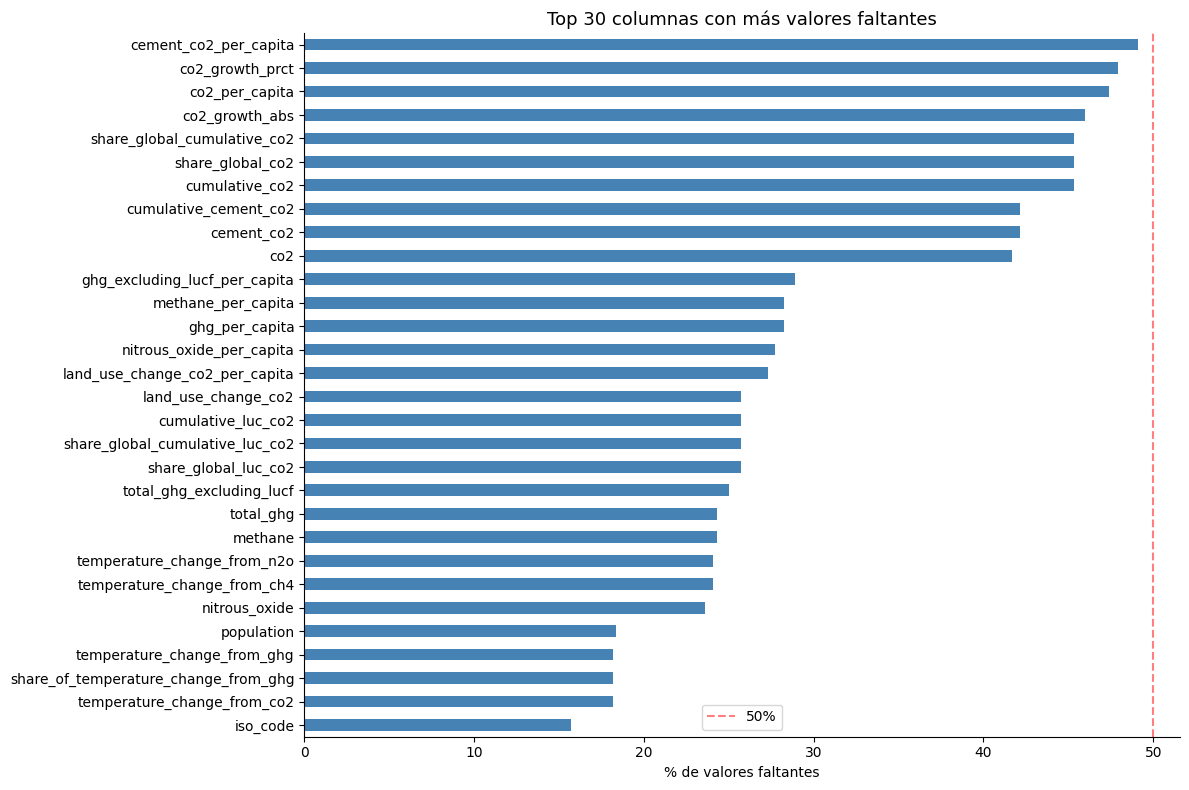

In [62]:
# === VALORES FALTANTES ===
# Calcular % de nulos por columna
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]  # Solo columnas con al menos un nulo

print(f"Columnas con valores faltantes: {len(missing)} de {df.shape[1]}")
print(f"Columnas sin ningún nulo:       {df.shape[1] - len(missing)}\n")

# Graficar las 30 columnas con más nulos
fig, ax = plt.subplots(figsize=(12, 8))
missing.sort_values(ascending=True).head(30).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Top 30 columnas con más valores faltantes', fontsize=13)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

### 1.3 Cobertura temporal y geográfica

In [63]:
# === COBERTURA TEMPORAL Y GEOGRÁFICA ===
print(f"Rango de años: {df['year'].min()} — {df['year'].max()}")
print(f"Países/regiones únicos: {df['country'].nunique()}")
print(f"\nPrimeros y últimos años con datos:")
print(df.groupby('year')['country'].count().head(5).to_string())
print("...")
print(df.groupby('year')['country'].count().tail(5).to_string())

Rango de años: 1750 — 2024
Países/regiones únicos: 254

Primeros y últimos años con datos:
year
1750    58
1751    58
1752    58
1753    58
1754    58
...
year
2020    254
2021    254
2022    254
2023    254
2024    254


In [64]:
# === IDENTIFICAR AGREGADOS REGIONALES ===
# OWID incluye no solo países sino también regiones agregadas
# (ej: "World", "Asia", "Europe") — hay que identificarlos para filtrarlos después

# Los agregados no tienen código ISO de 3 letras
aggregates = df[df['iso_code'].isna()]['country'].unique()
print(f"Agregados regionales encontrados ({len(aggregates)}):")
for a in sorted(aggregates):
    print(f"  - {a}")

Agregados regionales encontrados (36):
  - Africa
  - Africa (GCP)
  - Asia
  - Asia (GCP)
  - Asia (excl. China and India)
  - Central America (GCP)
  - Europe
  - Europe (GCP)
  - Europe (excl. EU-27)
  - Europe (excl. EU-28)
  - European Union (27)
  - European Union (28)
  - High-income countries
  - International aviation
  - International shipping
  - Kosovo
  - Kuwaiti Oil Fires
  - Kuwaiti Oil Fires (GCP)
  - Least developed countries (Jones et al.)
  - Low-income countries
  - Lower-middle-income countries
  - Middle East (GCP)
  - Non-OECD (GCP)
  - North America
  - North America (GCP)
  - North America (excl. USA)
  - OECD (GCP)
  - OECD (Jones et al.)
  - Oceania
  - Oceania (GCP)
  - Ryukyu Islands
  - Ryukyu Islands (GCP)
  - South America
  - South America (GCP)
  - Upper-middle-income countries
  - World


## 2. Filtros y limpieza

### 2.1 Eliminar agregados regionales

In [65]:
# === ELIMINAR AGREGADOS REGIONALES ===
# OWID incluye regiones agregadas (ej: "World", "Asia", "Europe")
# que no tienen código ISO — las eliminamos para quedarnos solo con países reales
df_countries = df[df['iso_code'].notna()].copy()

print(f"Dataset original:  {df.shape[0]:,} filas · {df['country'].nunique()} entidades")
print(f"Solo países:       {df_countries.shape[0]:,} filas · {df_countries['country'].nunique()} países")
print(f"Filas eliminadas:  {df.shape[0] - df_countries.shape[0]:,}")

Dataset original:  50,411 filas · 254 entidades
Solo países:       42,480 filas · 218 países
Filas eliminadas:  7,931


### 2.2 Filtro temporal: 1990–2022

In [66]:
# === FILTRO TEMPORAL ===
# Pre-1990: muy pocos países reportan datos completos
# Post-2022: datos incompletos (lag de publicación)
df_clean = df_countries[
    (df_countries['year'] >= 1990) &
    (df_countries['year'] <= 2022)
].copy()

print(f"Con filtro temporal: {df_clean.shape[0]:,} filas")
print(f"Años cubiertos:      {df_clean['year'].min()} — {df_clean['year'].max()}")
print(f"Países:              {df_clean['country'].nunique()}")

Con filtro temporal: 7,194 filas
Años cubiertos:      1990 — 2022
Países:              218


### 2.3 Selección de columnas para el EDA

No filtramos columnas pensando en el modelo (eso es tarea del TP3), sino que eliminamos únicamente:
- Columnas con **más del 70% de valores nulos** → insuficientes datos para analizar
- Columnas **duplicadas o casi idénticas** → misma información expresada de forma redundante

In [67]:
# === ELIMINAR COLUMNAS CON MÁS DEL 50% DE NULOS ===
thresh = 0.50
nulos_pct = df_clean.isnull().mean()
cols_muchos_nulos = nulos_pct[nulos_pct > thresh].index.tolist()

print(f"Columnas eliminadas por más del 50% de nulos ({len(cols_muchos_nulos)}):")
for col in cols_muchos_nulos:
    print(f"  {col:<45} {nulos_pct[col]*100:.1f}%")

df_clean = df_clean.drop(columns=cols_muchos_nulos)
print(f"\nColumnas restantes: {df_clean.shape[1]}")

Columnas eliminadas por más del 50% de nulos (5):
  cumulative_other_co2                          78.9%
  other_co2_per_capita                          78.9%
  other_industry_co2                            78.9%
  share_global_cumulative_other_co2             78.9%
  share_global_other_co2                        78.9%

Columnas restantes: 74


In [72]:
# === ELIMINAR COLUMNAS REDUNDANTES ===
cols_redundantes = [
    # Share global — ya tenemos los valores absolutos
    'share_global_cement_co2',
    'share_global_co2',
    'share_global_coal_co2',
    'share_global_flaring_co2',
    'share_global_oil_co2',
    'share_global_cumulative_cement_co2',
    'share_global_cumulative_co2_including_luc',
    'share_global_cumulative_coal_co2',
    'share_global_cumulative_flaring_co2',
    'share_global_cumulative_luc_co2',
    'share_global_cumulative_oil_co2',

    # Acumulados históricos — conservamos solo cumulative_co2
    'cumulative_cement_co2',
    'cumulative_co2_including_luc',
    'cumulative_coal_co2',
    'cumulative_flaring_co2',
    'cumulative_luc_co2',
    'cumulative_oil_co2',

    # Versiones "including_luc" — redundantes con las versiones base
    'co2_including_luc',
    'co2_including_luc_growth_abs',
    'co2_including_luc_growth_prct',
    'co2_including_luc_per_capita',
    'co2_including_luc_per_gdp',
    'co2_including_luc_per_unit_energy',

    # Temperature change — conservamos solo temperature_change_from_co2
    'temperature_change_from_ch4',
    'temperature_change_from_n2o',
    'temperature_change_from_ghg',
    'share_of_temperature_change_from_ghg',

    # GHG — conservamos ghg_per_capita, eliminamos los redundantes
    'total_ghg',
    'total_ghg_excluding_lucf',
    'ghg_excluding_lucf_per_capita',
]

# Solo eliminamos las que existen en el dataset actual
cols_redundantes = [c for c in cols_redundantes if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_redundantes)

print(f"Columnas redundantes eliminadas: {len(cols_redundantes)}")
print(f"Columnas finales para el EDA:    {df_clean.shape[1]}")
print(f"\nColumnas que conservamos:")
for i, col in enumerate(df_clean.columns):
    nulos = df_clean[col].isnull().mean() * 100
    print(f"  {i+1:>3}. {col:<45} {nulos:.1f}% nulos")

Columnas redundantes eliminadas: 30
Columnas finales para el EDA:    39

Columnas que conservamos:
    1. country                                       0.0% nulos
    2. year                                          0.0% nulos
    3. iso_code                                      0.0% nulos
    4. population                                    0.9% nulos
    5. gdp                                           24.8% nulos
    6. cement_co2                                    4.9% nulos
    7. cement_co2_per_capita                         5.8% nulos
    8. co2                                           1.6% nulos
    9. co2_growth_abs                                1.8% nulos
   10. co2_growth_prct                               2.4% nulos
   11. co2_per_capita                                2.5% nulos
   12. co2_per_gdp                                   24.8% nulos
   13. co2_per_unit_energy                           7.9% nulos
   14. coal_co2                                      37.8% nulos
  

### 2.4 Resumen del dataset limpio


In [73]:
# === RESUMEN FINAL ===
print(f"Dimensiones finales: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
print(f"Países:              {df_clean['country'].nunique()}")
print(f"Años:                {df_clean['year'].min()} — {df_clean['year'].max()}")
print(f"\nColumnas disponibles para el EDA:")
for i, col in enumerate(df_clean.columns):
    nulos = df_clean[col].isnull().mean() * 100
    print(f"  {i+1:>3}. {col:<45} {nulos:.1f}% nulos")

Dimensiones finales: 7,194 filas × 39 columnas
Países:              218
Años:                1990 — 2022

Columnas disponibles para el EDA:
    1. country                                       0.0% nulos
    2. year                                          0.0% nulos
    3. iso_code                                      0.0% nulos
    4. population                                    0.9% nulos
    5. gdp                                           24.8% nulos
    6. cement_co2                                    4.9% nulos
    7. cement_co2_per_capita                         5.8% nulos
    8. co2                                           1.6% nulos
    9. co2_growth_abs                                1.8% nulos
   10. co2_growth_prct                               2.4% nulos
   11. co2_per_capita                                2.5% nulos
   12. co2_per_gdp                                   24.8% nulos
   13. co2_per_unit_energy                           7.9% nulos
   14. coal_co2           

In [74]:
# === OBSERVACIÓN SOBRE LA VARIABLE RESPUESTA ===
con_target = df_clean['co2_per_capita'].notna().sum()
sin_target = df_clean['co2_per_capita'].isna().sum()

print(f"Filas con co2_per_capita conocido: {con_target:,}  → usadas para entrenar en TP3")
print(f"Filas con co2_per_capita nulo:     {sin_target:,}  → candidatas a predecir en TP3")

Filas con co2_per_capita conocido: 7,016  → usadas para entrenar en TP3
Filas con co2_per_capita nulo:     178  → candidatas a predecir en TP3


### 2.5 Snapshot del dataset limpio

In [75]:
df_clean.head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cumulative_gas_co2,share_global_gas_co2,temperature_change_from_co2,trade_co2_share
240,Afghanistan,1990,AFG,12045664.0,1.306598e+10,0.046,0.004,2.024,-0.741,-26.784,...,0.559,2.676,0.222,1.271,0.106,30.197,0.014,0.011,0.000,NaN
241,Afghanistan,1991,AFG,12238879.0,1.204736e+10,0.046,0.004,1.914,-0.110,-5.435,...,0.574,2.750,0.225,1.204,0.098,12.497,0.014,0.010,0.000,NaN
242,Afghanistan,1992,AFG,13278983.0,1.267754e+10,0.046,0.003,1.482,-0.432,-22.580,...,0.535,2.688,0.202,1.030,0.078,8.207,0.013,0.009,0.000,NaN
243,Afghanistan,1993,AFG,14943175.0,9.834582e+09,0.047,0.003,1.487,0.005,0.330,...,0.482,2.727,0.182,1.048,0.070,8.155,0.013,0.009,0.000,NaN
244,Afghanistan,1994,AFG,16250800.0,7.919856e+09,0.047,0.003,1.454,-0.033,-2.227,...,0.461,2.575,0.158,1.032,0.064,7.871,0.013,0.008,0.000,NaN
245,Afghanistan,1995,AFG,17065837.0,1.230753e+10,0.047,0.003,1.417,-0.037,-2.511,...,0.463,2.686,0.157,1.011,0.059,6.596,0.013,0.008,0.000,NaN
246,Afghanistan,1996,AFG,17763266.0,1.207013e+10,0.047,0.003,1.370,-0.047,-3.332,...,0.496,2.911,0.164,0.986,0.055,6.553,0.013,0.007,0.000,NaN
247,Afghanistan,1997,AFG,18452100.0,1.185075e+10,0.047,0.003,1.304,-0.066,-4.814,...,0.520,3.197,0.173,0.949,0.051,6.296,0.012,0.006,0.001,NaN
248,Afghanistan,1998,AFG,19159996.0,1.169217e+10,0.047,0.002,1.279,-0.026,-1.967,...,0.532,3.463,0.181,0.942,0.049,6.156,0.012,0.006,0.001,NaN
249,Afghanistan,1999,AFG,19887792.0,1.151732e+10,0.047,0.002,1.092,-0.187,-14.616,...,0.556,3.710,0.187,0.777,0.039,6.150,0.012,0.005,0.001,NaN


## 3. Análisis de la variable respuesta
La variable respuesta es `co2_per_capita`: toneladas de CO₂ per cápita por país y año.

### 3.1 Estadísticas descriptivas

In [76]:
# === ESTADÍSTICAS DESCRIPTIVAS DE LA VARIABLE RESPUESTA ===
target = df_clean['co2_per_capita'].dropna()

stats = {
    'Media':            target.mean(),
    'Mediana':          target.median(),
    'Desvío estándar':  target.std(),
    'Mínimo':           target.min(),
    'Máximo':           target.max(),
    'Skewness':         target.skew(),
    'Kurtosis':         target.kurt(),
    'Q1 (25%)':         target.quantile(0.25),
    'Q3 (75%)':         target.quantile(0.75),
    'IQR':              target.quantile(0.75) - target.quantile(0.25),
}

for k, v in stats.items():
    print(f"  {k:<22} {v:.3f}")

  Media                  5.047
  Mediana                2.713
  Desvío estándar        7.912
  Mínimo                 0.000
  Máximo                 364.791
  Skewness               15.324
  Kurtosis               616.950
  Q1 (25%)               0.701
  Q3 (75%)               6.925
  IQR                    6.224


### 3.2 Distribución

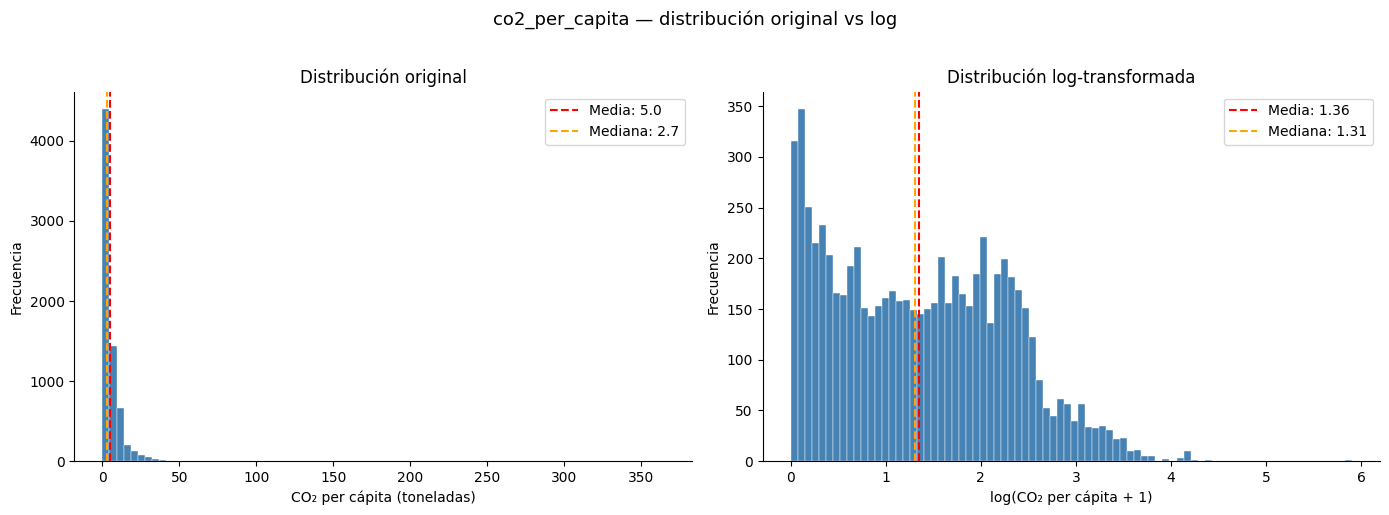


Skewness original:       15.32  → distribución muy asimétrica
Skewness log-transform:  0.33  → mucho más simétrica


In [77]:
# === DISTRIBUCIÓN DE co2_per_capita ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma — escala original
axes[0].hist(target, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(target.mean(),   color='red',    linestyle='--', label=f'Media: {target.mean():.1f}')
axes[0].axvline(target.median(), color='orange', linestyle='--', label=f'Mediana: {target.median():.1f}')
axes[0].set_xlabel('CO₂ per cápita (toneladas)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución original')
axes[0].legend()

# Histograma — escala logarítmica
log_target = np.log1p(target)
axes[1].hist(log_target, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(log_target.mean(),   color='red',    linestyle='--', label=f'Media: {log_target.mean():.2f}')
axes[1].axvline(log_target.median(), color='orange', linestyle='--', label=f'Mediana: {log_target.median():.2f}')
axes[1].set_xlabel('log(CO₂ per cápita + 1)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución log-transformada')
axes[1].legend()

plt.suptitle('co2_per_capita — distribución original vs log', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSkewness original:       {target.skew():.2f}  → distribución muy asimétrica")
print(f"Skewness log-transform:  {log_target.skew():.2f}  → mucho más simétrica")

### 3.3 Boxplot y detección de outliers

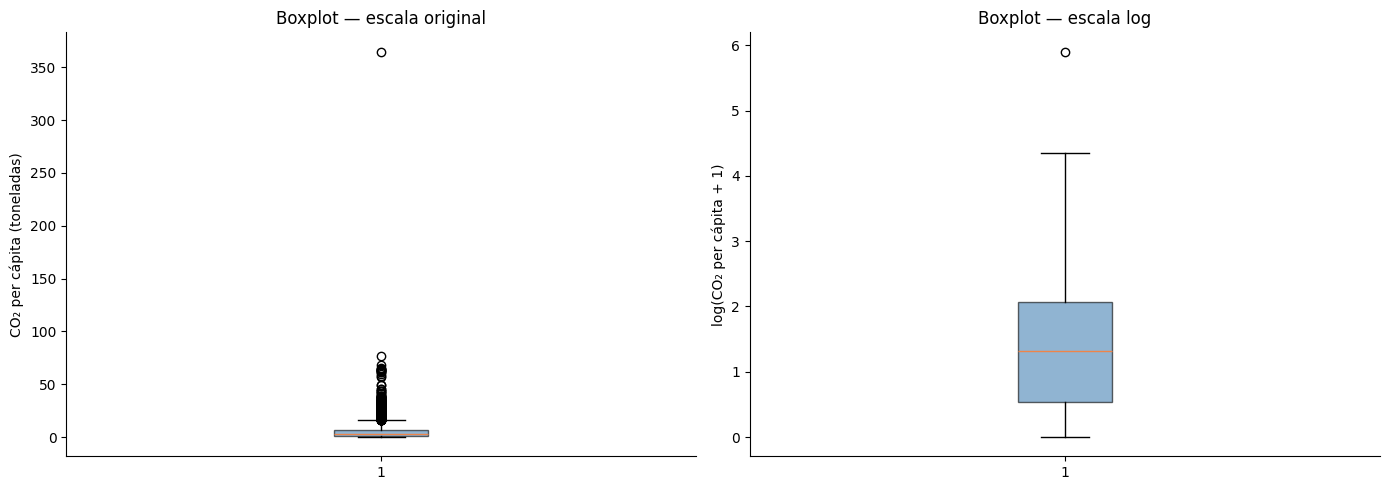

Límite superior IQR: 16.26 toneladas
Outliers detectados: 404 observaciones

Top 15 observaciones más extremas:
country  year  co2_per_capita
 Kuwait  1991         364.791
  Qatar  1997          76.715
  Qatar  2001          67.727
  Qatar  1996          65.162
  Qatar  1994          64.819
  Qatar  1995          64.491
  Qatar  1998          63.665
  Qatar  2002          63.518
  Qatar  1993          63.400
  Qatar  2000          62.646
  Qatar  2003          62.618
  Qatar  2006          61.421
  Qatar  2004          61.344
  Qatar  1999          59.305
  Qatar  2005          57.767


In [78]:
# === BOXPLOT Y OUTLIERS ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot original
axes[0].boxplot(target.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_ylabel('CO₂ per cápita (toneladas)')
axes[0].set_title('Boxplot — escala original')

# Boxplot log
axes[1].boxplot(log_target.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('log(CO₂ per cápita + 1)')
axes[1].set_title('Boxplot — escala log')

plt.tight_layout()
plt.show()

# Calcular outliers por IQR
Q1  = target.quantile(0.25)
Q3  = target.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

outliers = df_clean[df_clean['co2_per_capita'] > limite_superior][['country', 'year', 'co2_per_capita']]
print(f"Límite superior IQR: {limite_superior:.2f} toneladas")
print(f"Outliers detectados: {len(outliers):,} observaciones\n")
print("Top 15 observaciones más extremas:")
print(outliers.sort_values('co2_per_capita', ascending=False).head(15).to_string(index=False))

### 3.4 Evolución temporal

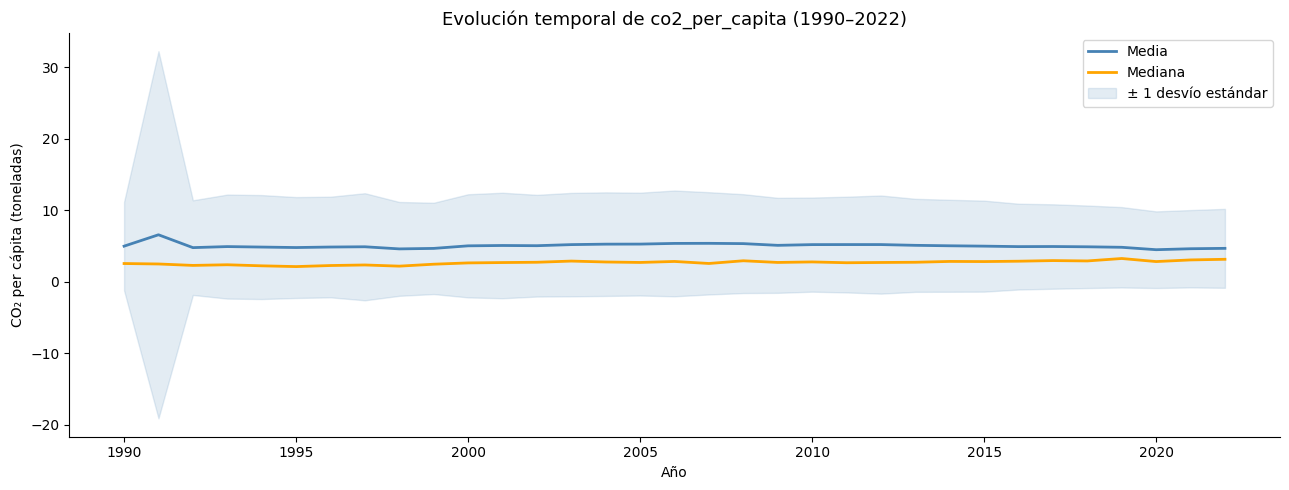

In [79]:
# === EVOLUCIÓN TEMPORAL DE co2_per_capita ===
evolucion = df_clean.groupby('year')['co2_per_capita'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(evolucion['year'], evolucion['mean'],   color='steelblue', label='Media',   linewidth=2)
ax.plot(evolucion['year'], evolucion['median'], color='orange',    label='Mediana', linewidth=2)
ax.fill_between(evolucion['year'],
                evolucion['mean'] - evolucion['std'],
                evolucion['mean'] + evolucion['std'],
                alpha=0.15, color='steelblue', label='± 1 desvío estándar')
ax.set_xlabel('Año')
ax.set_ylabel('CO₂ per cápita (toneladas)')
ax.set_title('Evolución temporal de co2_per_capita (1990–2022)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

In [80]:
df_clean.groupby('year')['co2_per_capita'].count().head(10)

,co2_per_capita
year,
1990,208
1991,209
1992,211
1993,211
1994,213
1995,213
1996,213
1997,213
1998,213


### 3.5 Países con emisiones más altas y más bajas

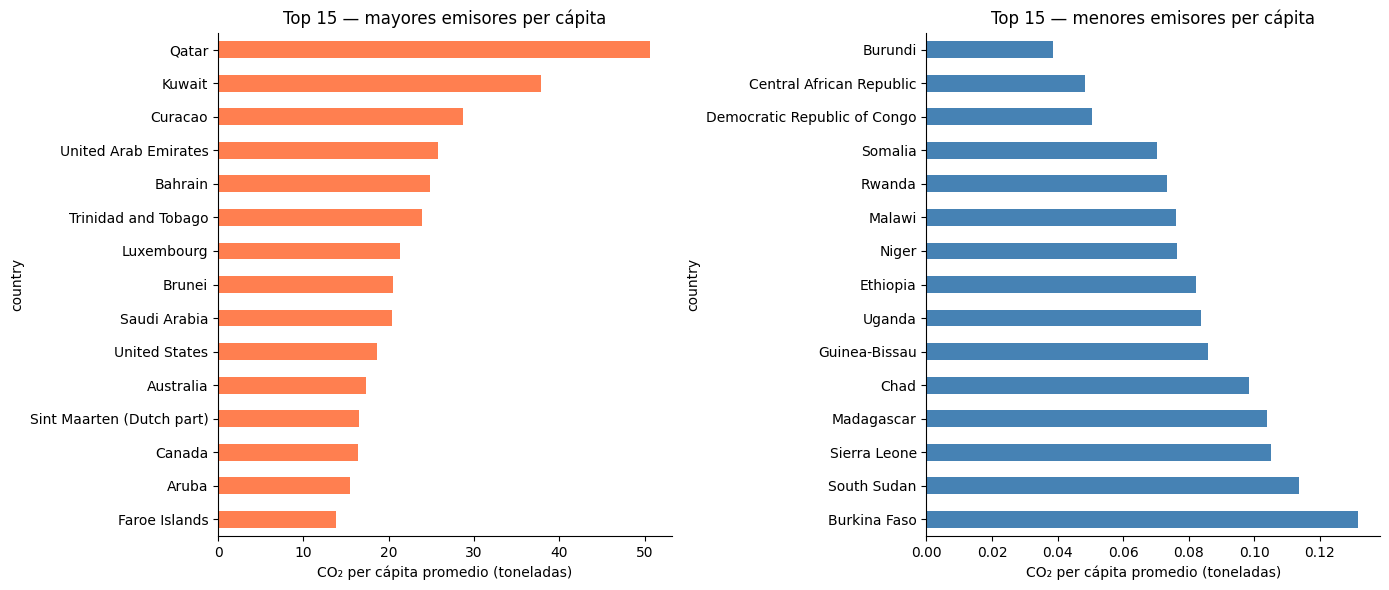


Top 5 mayores emisores:
country
Qatar                   50.62
Kuwait                  37.86
Curacao                 28.73
United Arab Emirates    25.81
Bahrain                 24.83

Top 5 menores emisores:
country
Rwanda                          0.07
Somalia                         0.07
Democratic Republic of Congo    0.05
Central African Republic        0.05
Burundi                         0.04


In [81]:
# === TOP Y BOTTOM PAÍSES (promedio 1990-2022) ===
promedio_pais = (df_clean.groupby('country')['co2_per_capita']
                 .mean()
                 .dropna()
                 .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 mayores emisores
promedio_pais.head(15).sort_values().plot(
    kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Top 15 — mayores emisores per cápita', fontsize=12)
axes[0].set_xlabel('CO₂ per cápita promedio (toneladas)')

# Top 15 menores emisores
promedio_pais.tail(15).sort_values(ascending=False).plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 — menores emisores per cápita', fontsize=12)
axes[1].set_xlabel('CO₂ per cápita promedio (toneladas)')

plt.tight_layout()
plt.show()

print("\nTop 5 mayores emisores:")
print(promedio_pais.head(5).round(2).to_string())
print("\nTop 5 menores emisores:")
print(promedio_pais.tail(5).round(2).to_string())

## 4. Análisis univariado de features
En esta sección analizamos la distribución individual de cada variable numérica relevante del dataset.

### 4.1 Visión general de todas las variables numéricas

In [82]:
# === VISIÓN GENERAL ===
# Estadísticas descriptivas de todas las variables numéricas
numericas = df_clean.select_dtypes(include='number').drop(columns=['year'])
numericas.describe().round(2)

,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_per_capita,co2_per_gdp,co2_per_unit_energy,...,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cumulative_gas_co2,share_global_gas_co2,temperature_change_from_co2,trade_co2_share
count,7.128000e+03,5.410000e+03,6844.00,6778.00,7078.00,7065.00,7019.00,7016.00,5409.00,6626.00,...,6567.00,6633.00,6633.00,7026.00,7008.00,6675.00,4000.00,4000.00,7095.00,3943.00
mean,3.092390e+07,4.894066e+11,5.07,0.11,135.39,2.11,3.77,5.05,0.35,0.23,...,1.83,12.69,0.50,46.18,2.76,636.47,0.82,0.82,0.00,25.35
std,1.241387e+08,1.704830e+12,37.21,0.17,656.52,32.16,30.98,7.91,1.17,0.19,...,2.91,39.98,0.60,185.19,5.58,2724.61,3.71,2.58,0.02,65.17
min,5.130000e+02,2.571720e+08,0.00,0.00,0.00,-545.96,-100.00,0.00,0.02,0.00,...,0.04,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,-98.28
25%,6.330200e+05,1.885143e+10,0.00,0.00,0.83,-0.09,-2.34,0.70,0.15,0.18,...,0.66,0.38,0.20,0.68,0.42,4.98,0.01,0.02,0.00,-5.71
50%,5.455912e+06,6.108450e+10,0.31,0.04,6.88,0.02,1.98,2.71,0.24,0.22,...,1.04,2.87,0.32,3.96,1.44,39.01,0.09,0.13,0.00,12.04
75%,1.964483e+07,2.913226e+11,1.75,0.15,53.77,0.74,7.23,6.93,0.39,0.25,...,1.71,9.46,0.53,23.86,3.53,303.55,0.47,0.66,0.00,36.96
max,1.426437e+09,2.696602e+13,828.71,1.46,11711.81,910.11,1550.84,364.79,82.60,10.69,...,42.77,466.88,5.40,2584.13,343.74,44516.49,47.97,27.72,0.24,1023.04


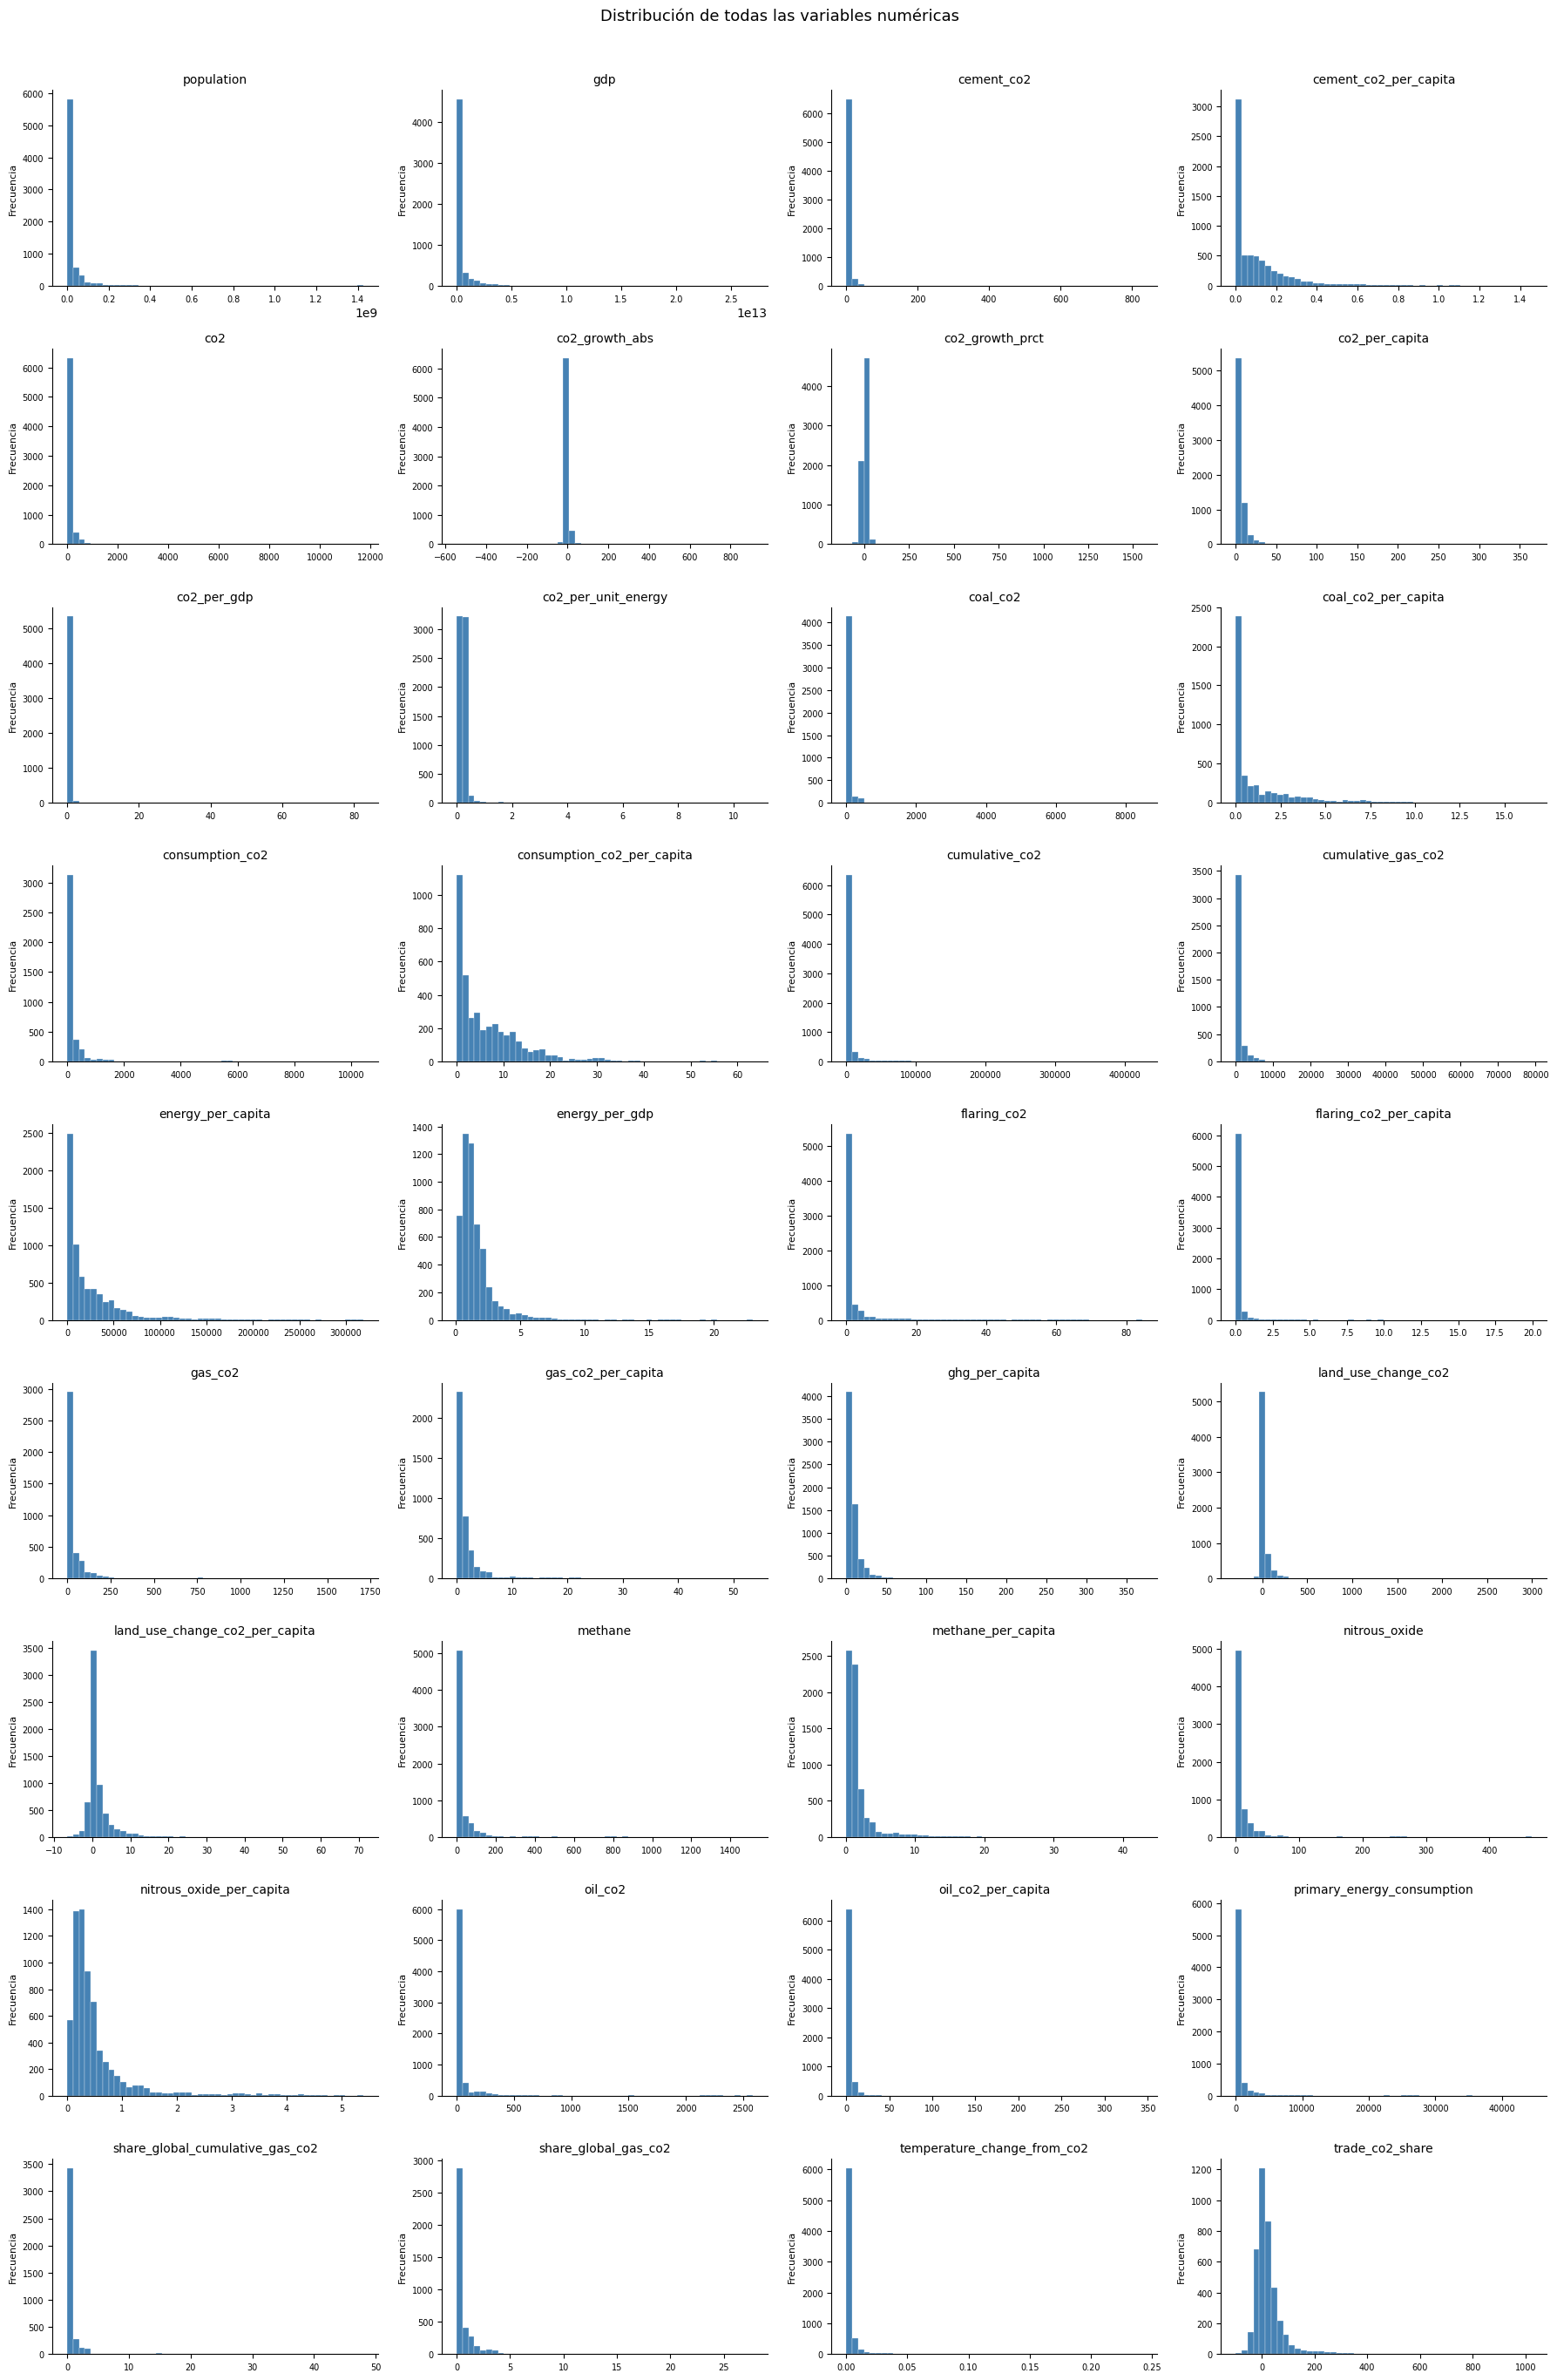

In [83]:
# === DISTRIBUCIÓN DE TODAS LAS VARIABLES NUMÉRICAS ===
# Grid de histogramas para tener una visión rápida de todas las variables
cols_plot = numericas.columns.tolist()
n_cols = 4
n_rows = -(-len(cols_plot) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    data = df_clean[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=8)
    axes[i].tick_params(labelsize=7)

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de todas las variables numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Skewness y necesidad de transformación

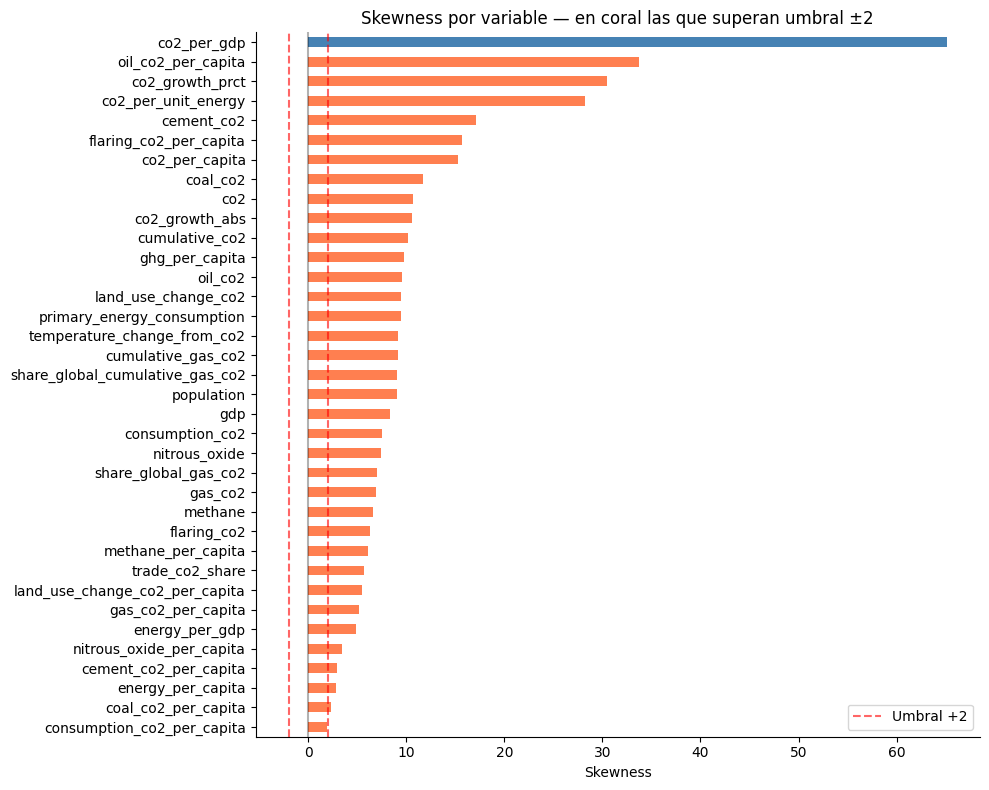

Variables con skewness > 2 (candidatas a transformación logarítmica):
co2_per_gdp                        65.14
oil_co2_per_capita                 33.78
co2_growth_prct                    30.48
co2_per_unit_energy                28.18
cement_co2                         17.11
flaring_co2_per_capita             15.72
co2_per_capita                     15.32
coal_co2                           11.68
co2                                10.65
co2_growth_abs                     10.57
cumulative_co2                     10.18
ghg_per_capita                      9.75
oil_co2                             9.56
land_use_change_co2                 9.44
primary_energy_consumption          9.42
temperature_change_from_co2         9.15
cumulative_gas_co2                  9.13
share_global_cumulative_gas_co2     9.05
population                          9.03
gdp                                 8.36
consumption_co2                     7.58
nitrous_oxide                       7.41
share_global_gas_co2        

In [84]:
# === SKEWNESS DE TODAS LAS VARIABLES ===
skewness = numericas.skew().sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(10, 8))
colores = ['coral' if abs(s) > 2 else 'steelblue' for s in skewness]
skewness.sort_values().plot(kind='barh', ax=ax, color=colores)
ax.axvline(x=2,  color='red',    linestyle='--', alpha=0.6, label='Umbral +2')
ax.axvline(x=-2, color='red',    linestyle='--', alpha=0.6)
ax.axvline(x=0,  color='black',  linestyle='-',  alpha=0.3)
ax.set_title('Skewness por variable — en coral las que superan umbral ±2', fontsize=12)
ax.set_xlabel('Skewness')
ax.legend()
plt.tight_layout()
plt.show()

print("Variables con skewness > 2 (candidatas a transformación logarítmica):")
print(skewness[abs(skewness) > 2].to_string())

### 4.3 Detección de outliers por IQR

In [85]:
# === DETECCIÓN DE OUTLIERS POR IQR ===
def calcular_outliers(serie):
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    lim_inf = Q1 - 1.5 * IQR
    n_outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    pct = n_outliers / serie.dropna().shape[0] * 100
    return pd.Series({
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lim_inf': lim_inf, 'lim_sup': lim_sup,
        'n_outliers': n_outliers, 'pct_outliers': pct
    })

resumen_outliers = numericas.apply(calcular_outliers).T
resumen_outliers = resumen_outliers.sort_values('pct_outliers', ascending=False)
resumen_outliers[['n_outliers', 'pct_outliers', 'lim_inf', 'lim_sup']].round(2)

,n_outliers,pct_outliers,lim_inf,lim_sup
co2_growth_abs,2072.0,29.33,-1.350000e+00,2.000000e+00
flaring_co2,1282.0,19.48,-8.600000e-01,1.440000e+00
flaring_co2_per_capita,1040.0,15.94,-6.000000e-02,1.000000e-01
coal_co2,690.0,15.41,-3.488000e+01,5.846000e+01
land_use_change_co2,994.0,15.29,-2.740000e+01,4.560000e+01
co2,1018.0,14.38,-7.858000e+01,1.331800e+02
cumulative_co2,1018.0,14.38,-2.825360e+03,4.768380e+03
cement_co2,976.0,14.26,-2.630000e+00,4.390000e+00
primary_energy_consumption,934.0,13.99,-4.428700e+02,7.514100e+02
gdp,745.0,13.77,-3.898554e+11,7.000295e+11


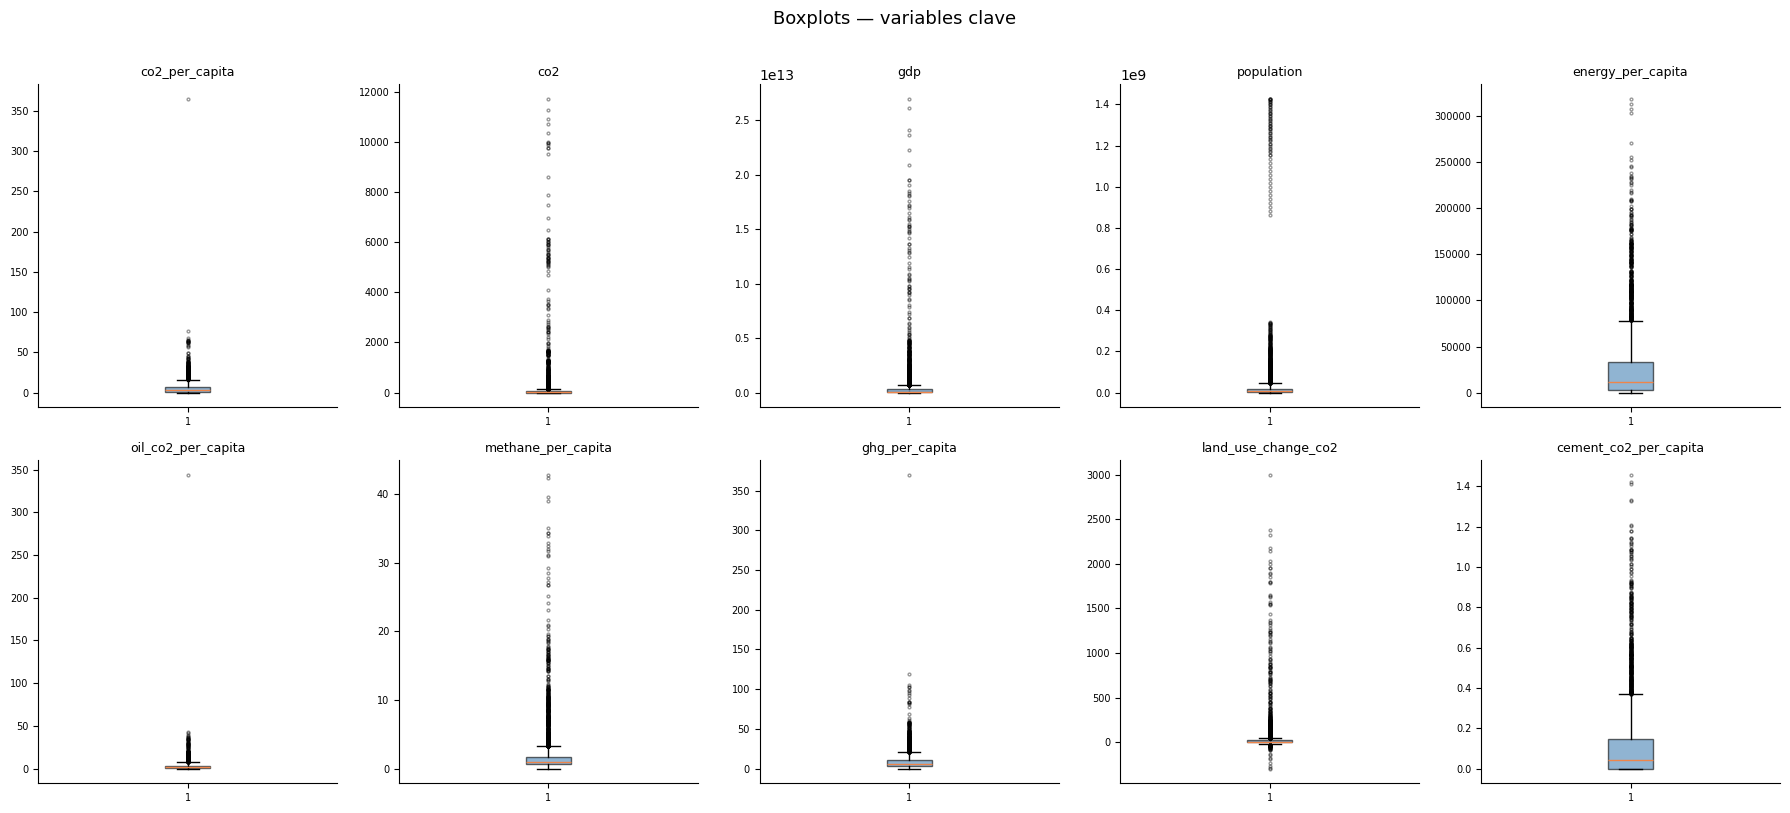

In [86]:
# === BOXPLOTS DE VARIABLES CLAVE ===
# Nos enfocamos en las variables más relevantes para el modelo
cols_key = [
    'co2_per_capita', 'co2', 'gdp', 'population',
    'energy_per_capita', 'oil_co2_per_capita',
    'methane_per_capita', 'ghg_per_capita',
    'land_use_change_co2', 'cement_co2_per_capita'
]
cols_key = [c for c in cols_key if c in df_clean.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_key):
    data = df_clean[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, color='coral'))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Boxplots — variables clave', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Análisis de variables económicas: GDP y población

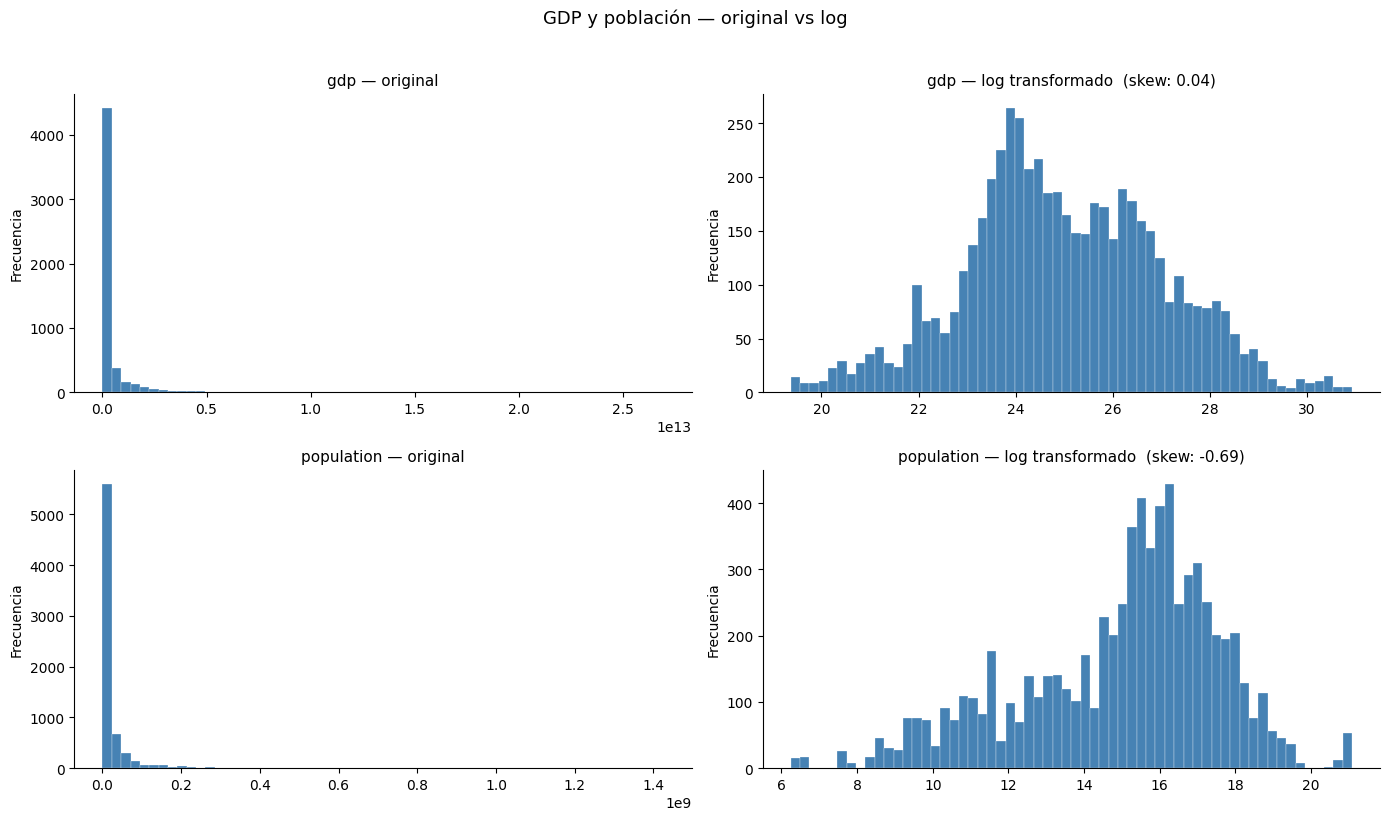

In [87]:
# === GDP Y POBLACIÓN ===
# Ambas variables tienen distribuciones muy asimétricas
# Analizamos original vs log para confirmar si conviene transformar

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(['gdp', 'population']):
    data = df_clean[col].dropna()

    # Original
    axes[i][0].hist(data, bins=60, color='steelblue', edgecolor='white', linewidth=0.2)
    axes[i][0].set_title(f'{col} — original', fontsize=11)
    axes[i][0].set_ylabel('Frecuencia')

    # Log
    log_data = np.log1p(data)
    axes[i][1].hist(log_data, bins=60, color='steelblue', edgecolor='white', linewidth=0.2)
    axes[i][1].set_title(f'{col} — log transformado  (skew: {log_data.skew():.2f})', fontsize=11)
    axes[i][1].set_ylabel('Frecuencia')

plt.suptitle('GDP y población — original vs log', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Análisis de variables energéticas

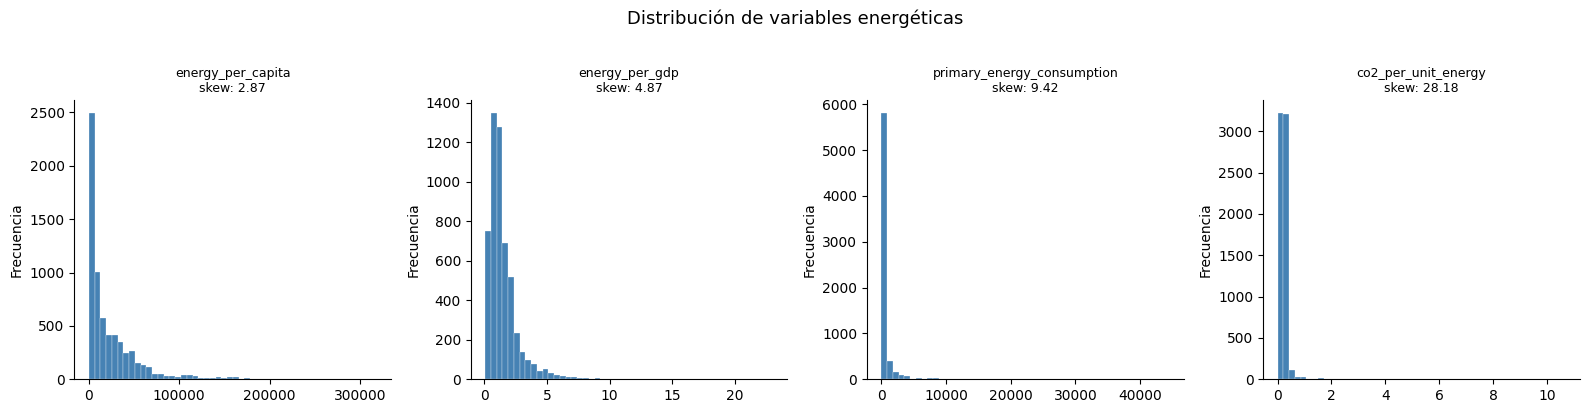

In [88]:
# === VARIABLES ENERGÉTICAS ===
cols_energia = [
    'energy_per_capita',
    'energy_per_gdp',
    'primary_energy_consumption',
    'co2_per_unit_energy'
]
cols_energia = [c for c in cols_energia if c in df_clean.columns]

fig, axes = plt.subplots(1, len(cols_energia), figsize=(16, 4))

for i, col in enumerate(cols_energia):
    data = df_clean[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.2)
    axes[i].set_title(f'{col}\nskew: {data.skew():.2f}', fontsize=9)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables energéticas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()